# Network Intrusion Detection using Random Forest
This notebook implements a Random Forest classifier for network intrusion detection using the CICIDS2017 cleaned dataset. It includes data loading, model training, evaluation, and feature importance analysis.

In [6]:
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Add src to path for imports
sys.path.insert(0, str(Path.cwd()))

from src.model_training import (
    load_and_split,
    evaluate_model,
    plot_confusion_matrix,
    compare_models
)

In [7]:
# Load and split the dataset
print("="*70)
print("STEP 1: Loading and splitting the CICIDS2017 cleaned dataset")
print("="*70)

X_train, X_test, y_train, y_test = load_and_split(
    data_path="cicids2017_cleaned.csv",
    target_col="Attack Type",
    test_size=0.2,
    random_state=42,
    save=False  # Set to False to avoid creating splits folder
)

print(f"\nFeature columns: {X_train.shape[1]}")
print(f"Classes: {sorted(y_train.unique())}")

STEP 1: Loading and splitting the CICIDS2017 cleaned dataset
Loading data from: cicids2017_cleaned.csv
  → Loaded 2,520,751 rows × 53 columns

Class distribution (%):
                 Full  Train   Test
Attack Type                        
Normal Traffic  83.11  83.11  83.11
DoS              7.69   7.69   7.69
DDoS             5.08   5.08   5.08
Port Scanning    3.60   3.60   3.60
Brute Force      0.36   0.36   0.36
Web Attacks      0.09   0.08   0.09
Bots             0.08   0.08   0.08

Train size: 2,016,600  |  Test size: 504,151


Feature columns: 52
Classes: ['Bots', 'Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scanning', 'Web Attacks']


In [8]:
print("\n" + "="*70)
print("STEP 2: Training Random Forest Classifier")
print("="*70)

t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\nTraining model on training set...")
rf_model.fit(X_train, y_train)

train_time = time.time() - t0
print(f"\n✓ Training completed in {train_time:.2f} seconds")


STEP 2: Training Random Forest Classifier

Training model on training set...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  7.0min



✓ Training completed in 702.82 seconds


[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed: 11.6min finished


In [9]:
print("\n" + "="*70)
print("STEP 3: Model Evaluation on Test Set")
print("="*70)

# Make predictions
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

# Evaluate model
rf_results = evaluate_model(
    y_true=y_test,
    y_pred=y_pred,
    model_name="Random Forest (n_estimators=300)",
    y_pred_proba=y_pred_proba,
    labels=rf_model.classes_.tolist(),
    print_report=True
)


STEP 3: Model Evaluation on Test Set


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    2.5s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    4.3s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    2.7s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    4.5s finished



  Random Forest (n_estimators=300) — Evaluation Results
                precision    recall  f1-score   support

          Bots       0.89      0.74      0.81       389
   Brute Force       1.00      1.00      1.00      1830
          DDoS       1.00      1.00      1.00     25603
           DoS       1.00      1.00      1.00     38749
Normal Traffic       1.00      1.00      1.00    419012
 Port Scanning       0.99      0.99      0.99     18139
   Web Attacks       0.99      0.97      0.98       429

      accuracy                           1.00    504151
     macro avg       0.98      0.96      0.97    504151
  weighted avg       1.00      1.00      1.00    504151

  Accuracy...................... 0.9985
  Precision (weighted).......... 0.9985
  Precision (macro)............. 0.982
  Recall (weighted)............. 0.9985
  Recall (macro)................ 0.9561
  F1 (weighted)................. 0.9985
  F1 (macro).................... 0.968
  Cohen Kappa................... 0.9951
  MCC.


STEP 4: Plotting Confusion Matrix


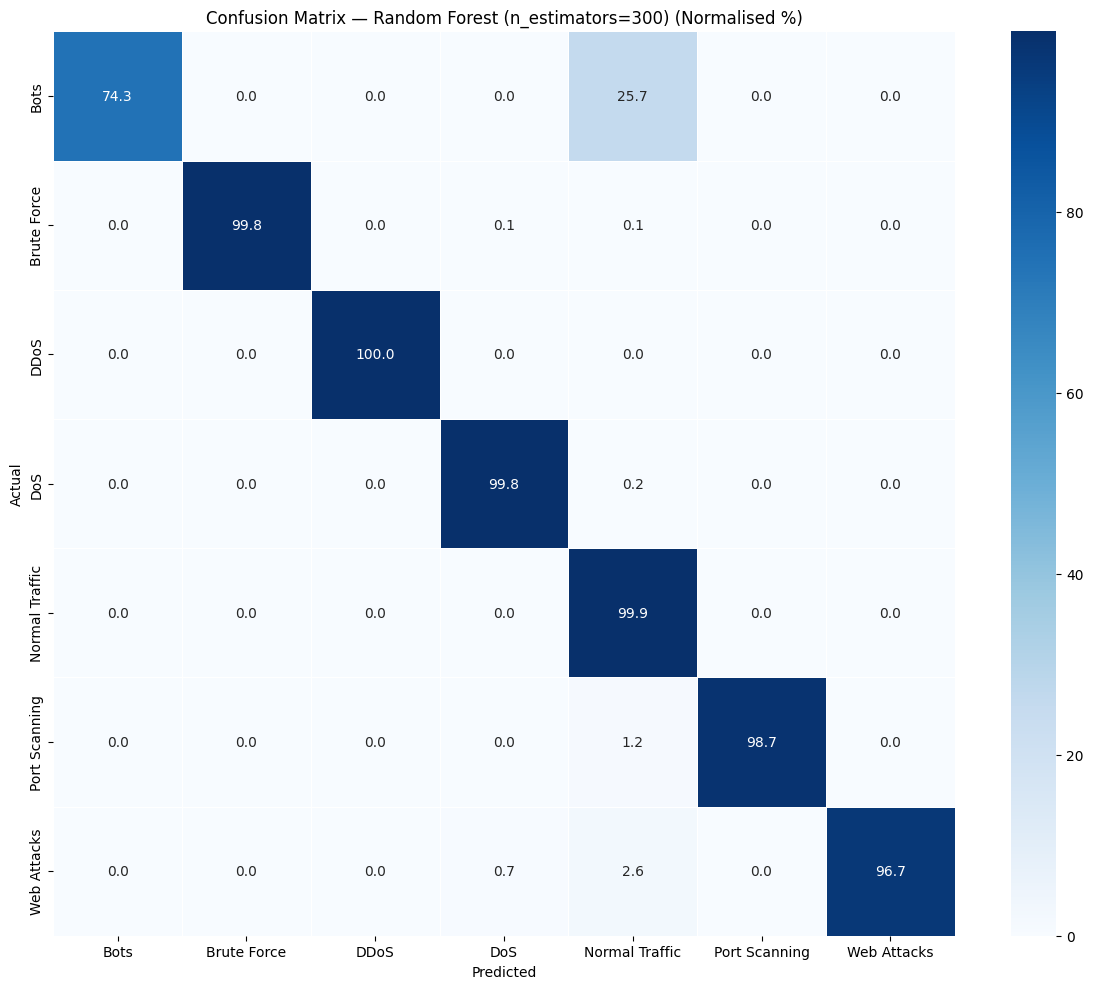

In [10]:
print("\n" + "="*70)
print("STEP 4: Plotting Confusion Matrix")
print("="*70)

plot_confusion_matrix(
    y_true=y_test,
    y_pred=y_pred,
    labels=rf_model.classes_.tolist(),
    model_name="Random Forest (n_estimators=300)",
    normalize=True,
    figsize=(12, 10),
    save_path=None
)


STEP 5: Feature Importance Analysis

Top 20 Most Important Features:
                    Feature  Importance
      Bwd Packet Length Std    0.074866
          Packet Length Std    0.069231
     Packet Length Variance    0.069157
      Bwd Packet Length Max    0.048151
     Bwd Packet Length Mean    0.046008
        Average Packet Size    0.045773
          Subflow Fwd Bytes    0.042349
Total Length of Fwd Packets    0.040290
          Max Packet Length    0.038338
      Fwd Packet Length Max    0.032203
         Packet Length Mean    0.029556
           Destination Port    0.026018
    Init_Win_bytes_backward    0.024170
                Fwd IAT Std    0.024167
          Bwd Header Length    0.021643
      Fwd Packet Length Std    0.021052
               Flow IAT Max    0.020171
          Total Fwd Packets    0.019814
           act_data_pkt_fwd    0.019284
          Fwd Header Length    0.019081


C:\Users\Admin\AppData\Local\Temp\ipykernel_29464\3941961904.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


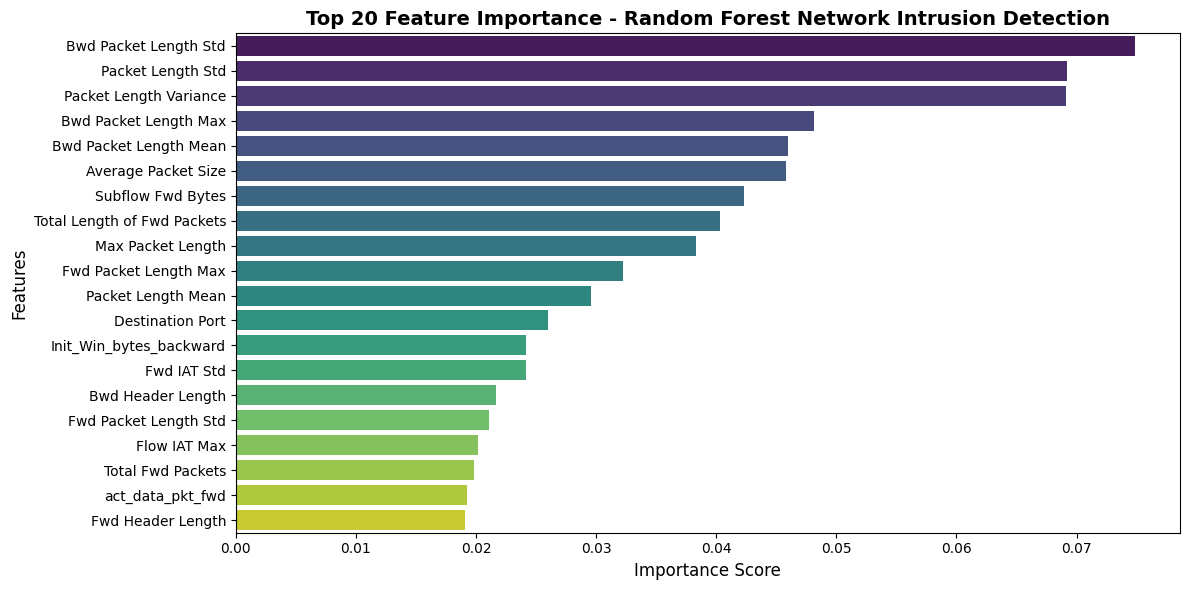

In [11]:
print("\n" + "="*70)
print("STEP 5: Feature Importance Analysis")
print("="*70)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feat_imp.head(20).to_string(index=False))

# Plot top 20 features
plt.figure(figsize=(12, 6))
sns.barplot(
    data=feat_imp.head(20),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title("Top 20 Feature Importance - Random Forest Network Intrusion Detection", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*70)
print("STEP 6: Model Comparison Summary")
print("="*70)

# Create comparison dataframe
comparison_df = compare_models([rf_results])

print("\nModel Comparison Results:")
print(comparison_df.to_string(index=False))

# Create a summary visualization
print("\n" + "="*70)
print("Training Summary")
print("="*70)
print(f"Total Training Time: {train_time:.2f} seconds")
print(f"Test Set Size: {len(y_test):,} samples")
print(f"Model Type: Random Forest")
print(f"Number of Estimators: 300")
print(f"Number of Features: {X_train.shape[1]}")
print(f"Number of Classes: {len(rf_model.classes_)}")
print("="*70)


STEP 6: Model Comparison Summary

Model Comparison Results:
                           Model  Accuracy  Precision (weighted)  Precision (macro)  Recall (weighted)  Recall (macro)  F1 (weighted)  F1 (macro)  Cohen Kappa    MCC  ROC-AUC (weighted)  ROC-AUC (macro)
Random Forest (n_estimators=300)    0.9985                0.9985              0.982             0.9985          0.9561         0.9985       0.968       0.9951 0.9951              0.9998           0.9996

Training Summary
Total Training Time: 702.82 seconds
Test Set Size: 504,151 samples
Model Type: Random Forest
Number of Estimators: 300
Number of Features: 52
Number of Classes: 7
